While waiting for Star Wars: The Force Awakens to come out, the team at FiveThirtyEight became interested in answering some questions about Star Wars fans. In particular, they wondered: does the rest of America realize that “The Empire Strikes Back” is clearly the best of the bunch?

The team needed to collect data addressing this question. To do this, they surveyed Star Wars fans using the online tool SurveyMonkey. They received 835 total responses, which you download from their [GitHub repository](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey).

In [1]:
import pandas as pd

#starwars = pd.read_csv('star_wars.csv')

# the CSV file contains some characters which are not part of Python's default utf-8 encoding
star_wars = pd.read_csv("star_wars.csv", encoding="ISO-8859-1")

In [4]:
star_wars.head(10)

,RespondentID,Have you seen any of the 6 films in the Star Wars franchise?,Do you consider yourself to be a fan of the Star Wars film franchise?,Which of the following Star Wars films have you seen? Please select all that apply.,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.,...,Unnamed: 28,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
0,3292879998,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3.0,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
1,3292879538,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
2,3292765271,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN,1.0,...,Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
3,3292763116,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5.0,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
4,3292731220,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5.0,...,Somewhat favorably,Greedo,Yes,No,No,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
5,3292719380,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,1.0,...,Very favorably,Han,Yes,No,Yes,Male,18-29,"$25,000 - $49,999",Bachelor degree,Middle Atlantic
6,3292684787,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,6.0,...,Very favorably,Han,Yes,No,No,Male,18-29,NaN,High school degree,East North Central
7,3292663732,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4.0,...,Very favorably,Han,No,NaN,Yes,Male,18-29,NaN,High school degree,South Atlantic
8,3292654043,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5.0,...,Somewhat favorably,Han,No,NaN,No,Male,18-29,"$0 - $24,999",Some college or Associate degree,South Atlantic
9,3292640424,Yes,No,NaN,Star Wars: Episode II Attack of the Clones,NaN,NaN,NaN,NaN,1.0,...,Very favorably,I don't understand this question,No,NaN,No,Male,18-29,"$25,000 - $49,999",Some college or Associate degree,Pacific

In [3]:
star_wars.columns

Index(['RespondentID',
       'Have you seen any of the 6 films in the Star Wars franchise?',
       'Do you consider yourself to be a fan of the Star Wars film franchise?',
       'Which of the following Star Wars films have you seen? Please select all that apply.',
       'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14',
       'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27',
       'Unnamed: 28', 'Which character shot first?',
       'Are you familiar with the Expan

The data has a total of 38 columns, some of them being as follows:

1. RespondentID - An anonymized ID for the respondent (person taking the survey)
2. Gender - The respondent's gender
3. Age - The respondent's age
4. Household Income - The respondent's income
5. Education - The respondent's education level
6. Location (Census Region) - The respondent's location
7. Have you seen any of the 6 films in the Star Wars franchise? - Has a Yes or No response
8. Do you consider yourself to be a fan of the Star Wars film franchise? - Has a Yes or No response

There are several colummns containing answers to questions about the Star Wars movies. For some questions, the respondent had to check one or more boxes.

#### Change columns with YES/NO answers to boolean

There are two columns which has possible `Yes/No` answers alongwith `NaNs`.
1. Do you consider yourself to be a fan of the Star Wars film franchise?
2. Have you seen any of the 6 films in the Star Wars franchise?

Lets map these columsn to boolean values, which makes our lives easier later down the line as would be able to select rows with True or False values without having to do string comparison

In [8]:
yes_no = {"Yes":True, "No":False}
star_wars['Do you consider yourself to be a fan of the Star Wars film franchise?'] = star_wars['Do you consider yourself to be a fan of the Star Wars film franchise?'].map(yes_no)
star_wars['Have you seen any of the 6 films in the Star Wars franchise?'] = star_wars['Have you seen any of the 6 films in the Star Wars franchise?'].map(yes_no)

In [9]:
star_wars['Have you seen any of the 6 films in the Star Wars franchise?'].value_counts()

True     936
False    250
Name: Have you seen any of the 6 films in the Star Wars franchise?, dtype: int64

In [10]:
star_wars['Do you consider yourself to be a fan of the Star Wars film franchise?'].value_counts()

True     552
False    284
Name: Do you consider yourself to be a fan of the Star Wars film franchise?, dtype: int64

Next few columns concern if the respondent has seen any of the Star War movies or not. The answers are organized as follows:
1. Which of the following Star Wars films have you seen? Please select all that apply. - Whether or not the respondent saw Star Wars: Episode I The Phantom Menace.
2. Unnamed: 4 - Whether or not the respondent saw Star Wars: Episode II Attack of the Clones.
3. Unnamed: 5 - Whether or not the respondent saw Star Wars: Episode III Revenge of the Sith.
4. Unnamed: 6 - Whether or not the respondent saw Star Wars: Episode IV A New Hope.
5. Unnamed: 7 - Whether or not the respondent saw Star Wars: Episode V The Empire Strikes Back.
6. Unnamed: 8 - Whether or not the respondent saw Star Wars: Episode VI Return of the Jedi.

For each of these columns, if the value in a cell is the name of the movie, that means the respondent saw the movie. If the value is NaN, the respondent either didn't answer or didn't see the movie. I'll assume that they didn't see the movie.

In [11]:
star_wars['Which of the following Star Wars films have you seen? Please select all that apply.'].value_counts()

Star Wars: Episode I  The Phantom Menace    673
Name: Which of the following Star Wars films have you seen? Please select all that apply., dtype: int64

In [21]:
star_wars['seen_6'].value_counts()

Star Wars: Episode VI Return of the Jedi    738
Name: seen_6, dtype: int64

Let me first rename columns to something more sensible like the 'seen_1', 'seen_2' and so on, to reflect whether the user has seen the movie or not.

In [15]:
column_mapping = {'Which of the following Star Wars films have you seen? Please select all that apply.':'seen_1',
                 'Unnamed: 4':'seen_2',
                 'Unnamed: 5':'seen_3',
                 'Unnamed: 6':'seen_4',
                 'Unnamed: 7':'seen_5',
                 'Unnamed: 8':'seen_6'}
star_wars.rename(columns=column_mapping, inplace=True)
star_wars.columns

Index(['RespondentID',
       'Have you seen any of the 6 films in the Star Wars franchise?',
       'Do you consider yourself to be a fan of the Star Wars film franchise?',
       'seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6',
       'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14',
       'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27',
       'Unnamed: 28', 'Which character shot first?',
       'Are you familiar with the Expanded Universe?',
       'Do you consider yourself to be a fan of the Expanded Universe?',
       'Do you 

Now I will change the values to boolean values.

In [23]:
import numpy as np
star_wars['seen_1'] = star_wars['seen_1'].map({'Star Wars: Episode I  The Phantom Menace':True, np.NaN:False})
star_wars['seen_2'] = star_wars['seen_2'].map({'Star Wars: Episode II  Attack of the Clones':True, np.NaN:False})
star_wars['seen_3'] = star_wars['seen_3'].map({'Star Wars: Episode III  Revenge of the Sith':True, np.NaN:False})
star_wars['seen_4'] = star_wars['seen_4'].map({'Star Wars: Episode IV  A New Hope':True, np.NaN:False})
star_wars['seen_5'] = star_wars['seen_5'].map({'Star Wars: Episode V The Empire Strikes Back':True, np.NaN:False})
star_wars['seen_6'] = star_wars['seen_6'].map({'Star Wars: Episode VI Return of the Jedi':True, np.NaN:False})

In [24]:
star_wars['seen_4'].value_counts()

True     607
False    579
Name: seen_4, dtype: int64

In [25]:
star_wars['seen_2'].value_counts()

False    615
True     571
Name: seen_2, dtype: int64

Next few columns contains answers about how the user ranked the movies in the franchise, with 1 meaning the favorite movie and 6 meaning the least favorite movie. For these columns I will just convert the column type to numeric and rename the columns to make more sense like 'ranking_1', 'ramking_2'.

In [26]:
star_wars[star_wars.columns[9:15]] = star_wars[star_wars.columns[9:15]].astype(float)

In [38]:
column_mapping = {'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.':'ranking_1',
                 'Unnamed: 10':'ranking_2',
                 'Unnamed: 11':'ranking_3',
                 'Unnamed: 12':'ranking_4',
                 'Unnamed: 13':'ranking_5',
                 'Unnamed: 14':'ranking_6'}
star_wars.rename(columns=column_mapping, inplace=True)

#### Highest ranked movies

In [52]:
avg_rankings = star_wars[star_wars.columns[9:15]].mean()

<AxesSubplot:>

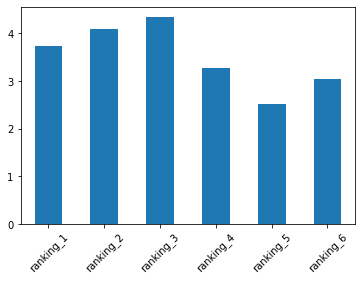

In [53]:
%matplotlib inline 

avg_rankings.plot.bar(rot=45)

From the bar plot we can see the lowest average, around 2.5 (which implies highest ranking) is for the movie 5, Star Wars: Episode V The Empire Strikes Back.

Films: Star Wars: Episode IV A New Hope and Star Wars: Episode VI Return of the Jedi got also high marks - (both around 3.0). Whereas, Episode I The Phantom Menace, Episode II Attack of the Clones and Episode III Revenge of the Sith have been the lowest-rated. Part III got the worst score - over 4.0.

When we check chronology of film [releases](https://pl.wikipedia.org/wiki/Gwiezdne_wojny#Filmy'), we found that Episodes IV, V and VI were released much earlier than 3 others. Moreover, Episode III, which was released the latest, in 2005 got the worst score. So the users have more fondness for the older movies.

#### Highest viewed movies

In [58]:
movie_views = star_wars[star_wars.columns[3:9]]

<AxesSubplot:>

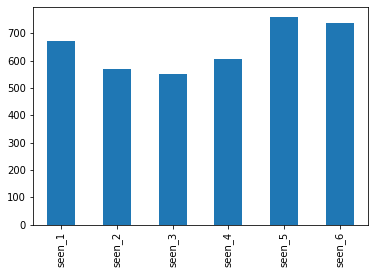

In [62]:
movie_views.sum().plot.bar()

Most viewed movies of the franchise are part 5 and 6 which are also the highest rated movies & part 3 is the least watched movie which as the lowest ranking. So there is clear positive correlation between the number of view and ranking of the movies.